# Лабораторная работа №5 - Кластеризация

В этом задании дан датасет с синтетическими (специально сгенерированными) 
данными. 


**Легенда**

Учёный решил провести кластеризацию некоторого множества звёзд по их 
расположению на карте звёздного неба. Кластер звёзд – это набор звёзд (точек) на карте, 
лежащий внутри круга некоторого радиуса. Каждая звезда принадлежит ровно одному 
кластеру. Под расстоянием понимается расстояние Евклида. 


**Описание входных данных**

В файле хранятся данные о звёздах трёх кластеров. В каждой строке записана 
информация о расположении на карте одной звезды: сначала координата x, затем 
координата y. Значения даны в условных единицах.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1. Загрузка данных

Поскольку данные синтетические и специально подготовленные, то никакую 
предварительную обработку проводить не нужно. Однако, проверьте 
правильность загрузки данных и их тип. 

In [ ]:
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,X,Y
0,"7,084","7,959"
1,"-0,759","5,781"
2,"6,736","4,64"
3,"7,899","7,361"
4,"0,297","5,932"


In [4]:
print(df.shape)

(9900, 2)


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X       9900 non-null   str  
 1   Y       9900 non-null   str  
dtypes: str(2)
memory usage: 154.8 KB


In [17]:
def parse_type(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return np.nan

df['X'] = df['X'].apply(parse_type)
df['Y'] = df['Y'].apply(parse_type)
df.dtypes

X    float64
Y    float64
dtype: object

## 2. Кластеризация

Из библиотеки sklearn.cluster возьмите алгоритм кластеризации KMeans. 
Постройте модель. Количество кластеров нужно задать исходя из описания 
входных данных. Начальный выбор центроидов – случайный. Получите разбиение 
на кластеры. 

In [19]:
data = df.values
kmeans_3 = KMeans(n_clusters=3, init='random', random_state=42)
labels_3 = kmeans_3.fit_predict(data)

Постройте точечный график, на котором выведите все звёзды (по одной оси – 
x-координаты звёзд, по другой – y-координаты, цвет точек соответствует 
кластеру). 

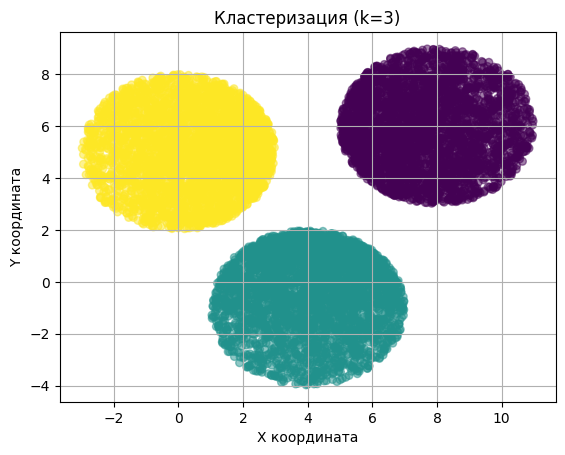

In [34]:
plt.scatter(data[:, 0], data[:, 1], c=labels_3, alpha=0.5, s=30)
plt.title('Кластеризация (k=3)')
plt.xlabel('X координата')
plt.ylabel('Y координата')
plt.grid(True)

## 3. Подсчет метрики качества

 Метрикой качества для задачи кластеризации является «силуэт». Посчитайте 
значение этого показателя для полученного разбиения на кластеры (функция 
silhouette_score из библиотеки sklearn.metrics). 

In [23]:
score_3 = silhouette_score(data, labels_3)
print(f"Silhouette Score для k=3: {score_3:.4f}")

Silhouette Score для k=3: 0.6000


| Значение | Интерпретация |
| :--- | :--- |
| **Близко к 1** | **Отлично.** Кластеры плотные и хорошо разделены. Точки находятся близко к своим соседям в кластере и далеко от точек других кластеров. |
| **Близко к 0** | **Нейтрально.** Кластеры перекрываются. Расстояние до своих соседей примерно равно расстоянию до соседей из ближайшего чужого кластера. |
| **Близко к -1** | **Плохо.** Точки, скорее всего, назначены не в те кластеры. Точка находится ближе к другому кластеру, чем к своему. |

## 4. Разбиение на другое количество кластеров

Попробуйте выполнить разбиение на другое количество кластеров (например, 5). 
Посмотрите, как изменился показатель силуэт. 

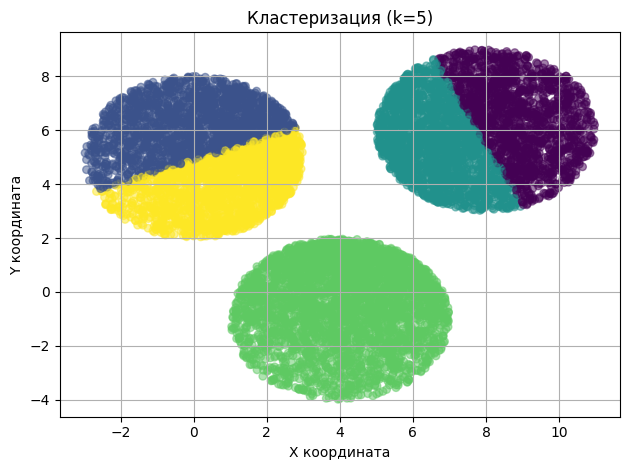

In [33]:
kmeans_5 = KMeans(n_clusters=5, init='random', random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(data)

plt.scatter(data[:, 0], data[:, 1], c=labels_5, alpha=0.5, s=30)
plt.title('Кластеризация (k=5)')
plt.xlabel('X координата')
plt.ylabel('Y координата')
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
score_5 = silhouette_score(data, labels_5)
print(f"Silhouette Score для k=5: {score_5:.4f}")

Silhouette Score для k=5: 0.3985


## 5. Дополнительное задание

Реализуйте алгоритм k-means самостоятельно (то есть напишите свою реализацию 
этого метода). Реализация должна решать данную конкретную задачу (то есть не нужно 
стараться сделать полный аналог библиотечной функции, не нужно никаких 
параметров). Сравните результат своей реализации со стандартной

In [35]:
data

array([[ 7.084,  7.959],
       [-0.759,  5.781],
       [ 6.736,  4.64 ],
       ...,
       [-0.361,  5.778],
       [ 7.805,  6.691],
       [ 2.113,  6.23 ]], shape=(9900, 2))

In [38]:
data.shape[0]

9900

In [39]:
np.random.choice(data.shape[0], 5, replace=False)

array([ 810, 6549, 1333, 7215, 2399], dtype=int32)

In [41]:
data[np.random.choice(data.shape[0], 5, replace=False)]

array([[ 1.667,  3.724],
       [ 9.454,  4.012],
       [ 4.278,  0.095],
       [ 5.553,  7.383],
       [ 4.19 , -1.6  ]])

In [43]:
def k_means(X, n_clusters = 3, max_iters=100):
    np.random.seed(42)
    # Инициализируем центроиды случайно
    random_indices = np.random.choice(X.shape[0], n_clusters, replace=False)
    centroids = X[random_indices]

    for _ in range(max_iters):
        labels = []  # Здесь будем хранить номер кластера для каждой точки

        #расстояние до цетроиндов
        for point in X:
            distances = []  
            for c in centroids:
                distances.append(np.sqrt((c[0] - point[0])**2 + (c[1] - point[1])**2))            
            
            # Находим индекс центроида с минимальным расстоянием
            # Это и будет номер кластера для данной точки
            cluster_label = np.argmin(distances)
            labels.append(cluster_label)

        labels = np.array(labels)
        new_centroids = np.zeros_like(centroids)
        for i in range(n_clusters):
            # Берем все точки, которые принадлежат кластеру i
            points_in_cluster = X[labels == i]
            
            if len(points_in_cluster) > 0:
                # Новый центроид = среднее арифметическое всех точек кластера
                new_centroids[i] = points_in_cluster.mean(axis=0)
            else:
                # Если кластер пуст, оставляем старый центроид
                new_centroids[i] = centroids[i]

        # Если центроиды не изменились — алгоритм сошелся
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
    
    return labels, centroids        

In [44]:
my_labels, my_centroids = k_means(data)
my_score = silhouette_score(X, my_labels)
print(f"Silhouette Score (Моя реализация, k=3): {my_score:.4f}")
print(f"Silhouette Score (Sklearn, k=3):          {score_3:.4f}")

Silhouette Score (Моя реализация, k=3): 0.6000
Silhouette Score (Sklearn, k=3):          0.6000


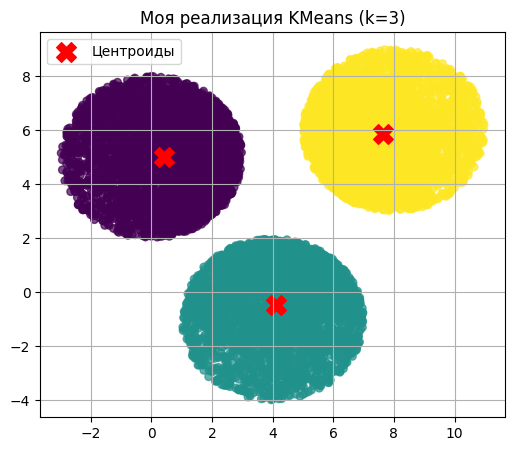

In [45]:
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], c=my_labels, s=30, alpha=0.7)
# Отрисуем центроиды крестиками
plt.scatter(my_centroids[:, 0], my_centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
plt.title('Моя реализация KMeans (k=3)')
plt.legend()
plt.grid(True)
plt.show()